In [2]:
%pip install matplotlib
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns   

In [4]:
df=pd.read_csv('meningitis_dataset (1).csv')
df.drop(columns=['id'], inplace=True)
df.head()

,surname,firstname,middlename,gender,gender_male,gender_female,state,settlement,rural_settlement,urban_settlement,...,NmA,NmC,NmW,health_status,alive,dead,report_outcome,unconfirmed,confirmed,null_serotype
0,Solade,Grace,Solape,Female,0,1,Rivers,Rural,1,0,...,0,0,0,alive,1,0,confirmed,0,1,1
1,Eneche,Kure,Balogun,Male,1,0,Ebonyi,Rural,1,0,...,0,0,1,Alive,1,0,Confirmed,1,0,1
2,Sanusi,Adaugo,Katerine,Female,0,1,Ogun,Urban,0,1,...,0,0,1,Dead,0,1,Not Confirmed,1,0,1
3,Sowore,Mooslemat,Ifedayo,Female,0,1,Ondo,Rural,1,0,...,0,0,1,Alive,1,0,Not Confirmed,1,0,1
4,Abdusalam,Yusuf,Okafor,Male,1,0,Oyo,Urban,0,1,...,0,0,1,Alive,1,0,Confirmed,1,0,1


In [5]:
print('shape of the dataset', df.shape)
print('\n')
print(df.info())

shape of the dataset (195, 39)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   surname                     195 non-null    object
 1   firstname                   195 non-null    object
 2   middlename                  195 non-null    object
 3   gender                      195 non-null    object
 4   gender_male                 195 non-null    int64 
 5   gender_female               195 non-null    int64 
 6   state                       195 non-null    object
 7   settlement                  195 non-null    object
 8   rural_settlement            195 non-null    int64 
 9   urban_settlement            195 non-null    int64 
 10  report_date                 195 non-null    object
 11  report_year                 195 non-null    int64 
 12  age                         195 non-null    int64 
 13  age_str          

In [6]:
print(df.columns)

Index(['surname', 'firstname', 'middlename', 'gender', 'gender_male',
       'gender_female', 'state', 'settlement', 'rural_settlement',
       'urban_settlement', 'report_date', 'report_year', 'age', 'age_str',
       'date_of_birth', 'child_group', 'adult_group', 'disease', 'cholera',
       'diarrhoea', 'measles', 'viral_haemmorrhaphic_fever', 'meningitis',
       'ebola', 'marburg_virus', 'yellow_fever', 'rubella_mars', 'malaria',
       'serotype', 'NmA', 'NmC', 'NmW', 'health_status', 'alive', 'dead',
       'report_outcome', 'unconfirmed', 'confirmed', 'null_serotype'],
      dtype='object')


In [7]:
print(df.describe())

       gender_male  gender_female  rural_settlement  urban_settlement  \
count   195.000000     195.000000        195.000000        195.000000   
mean      0.451282       0.548718          0.482051          0.517949   
std       0.498902       0.498902          0.500964          0.500964   
min       0.000000       0.000000          0.000000          0.000000   
25%       0.000000       0.000000          0.000000          0.000000   
50%       0.000000       1.000000          0.000000          1.000000   
75%       1.000000       1.000000          1.000000          1.000000   
max       1.000000       1.000000          1.000000          1.000000   

       report_year         age  child_group  adult_group     cholera  \
count   195.000000  195.000000   195.000000   195.000000  195.000000   
mean   2013.758974   32.882051     0.317949     0.682051    0.133333   
std       2.878709   21.892225     0.466878     0.466878    0.340810   
min    2009.000000    2.000000     0.000000     0.0000

In [8]:
print("missing values per col")
print(df.isnull().sum())
print("\n")
print('total missing values on dataset',df.isnull().sum().sum())

missing values per col
surname                       0
firstname                     0
middlename                    0
gender                        0
gender_male                   0
gender_female                 0
state                         0
settlement                    0
rural_settlement              0
urban_settlement              0
report_date                   0
report_year                   0
age                           0
age_str                       0
date_of_birth                 0
child_group                   0
adult_group                   0
disease                       0
cholera                       0
diarrhoea                     0
measles                       0
viral_haemmorrhaphic_fever    0
meningitis                    0
ebola                         0
marburg_virus                 0
yellow_fever                  0
rubella_mars                  0
malaria                       0
serotype                      0
NmA                           0
NmC              

In [9]:
duplicates = df.duplicated().sum()

print(duplicates)

0


In [10]:
df = df.drop_duplicates()

In [11]:
print(df.dtypes)


surname                       object
firstname                     object
middlename                    object
gender                        object
gender_male                    int64
gender_female                  int64
state                         object
settlement                    object
rural_settlement               int64
urban_settlement               int64
report_date                   object
report_year                    int64
age                            int64
age_str                       object
date_of_birth                 object
child_group                    int64
adult_group                    int64
disease                       object
cholera                        int64
diarrhoea                      int64
measles                        int64
viral_haemmorrhaphic_fever     int64
meningitis                     int64
ebola                          int64
marburg_virus                  int64
yellow_fever                   int64
rubella_mars                   int64
m

In [12]:
for col in ["report_date", "date_of_birth"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[["report_date", "date_of_birth"]].isna().sum())

report_date      1
date_of_birth    4
dtype: int64


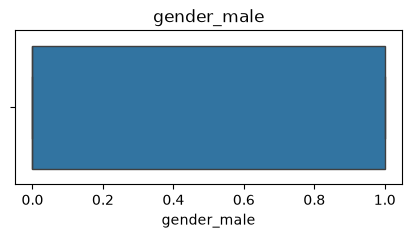

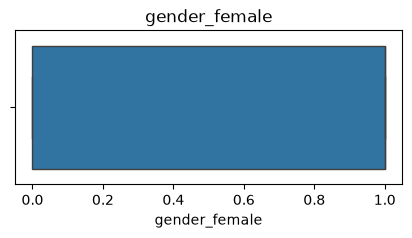

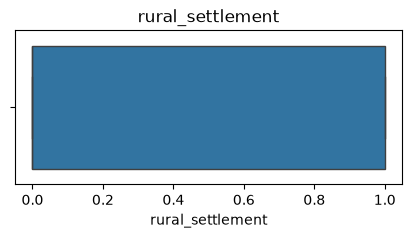

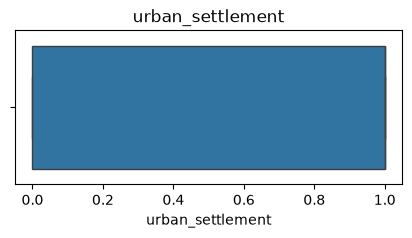

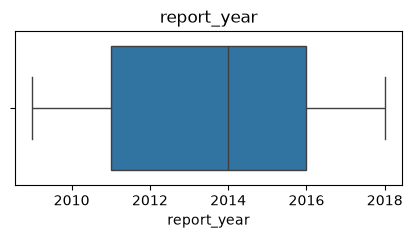

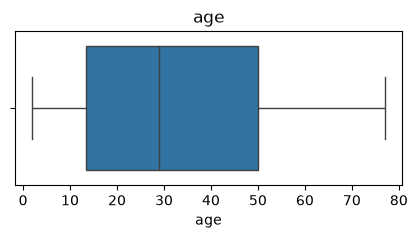

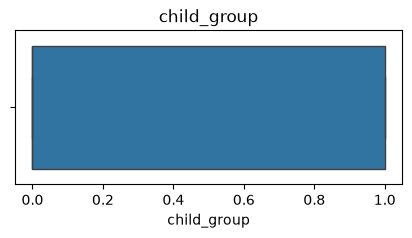

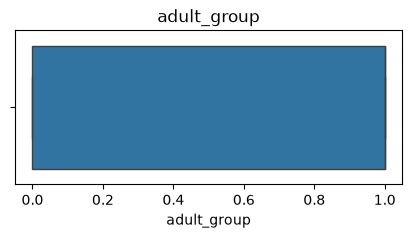

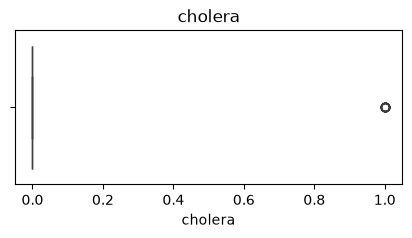

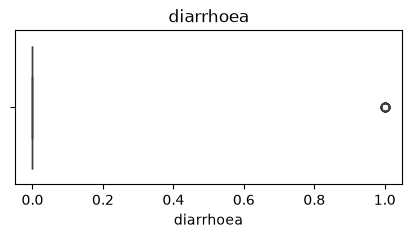

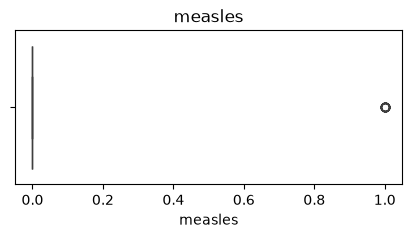

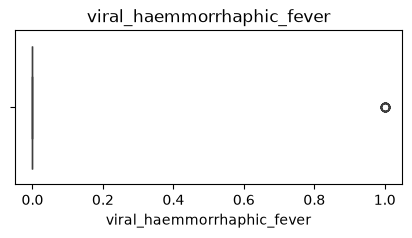

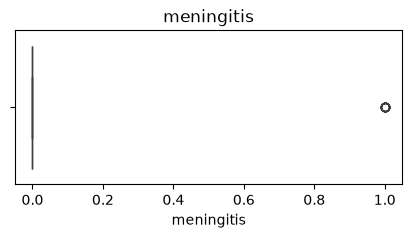

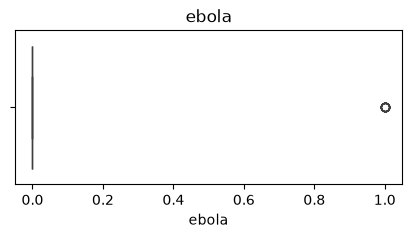

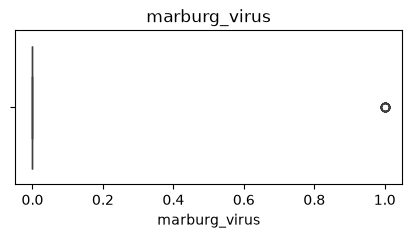

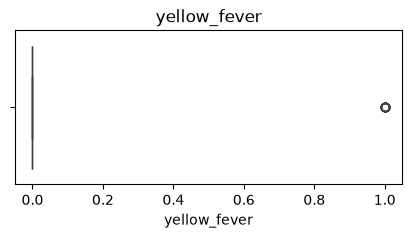

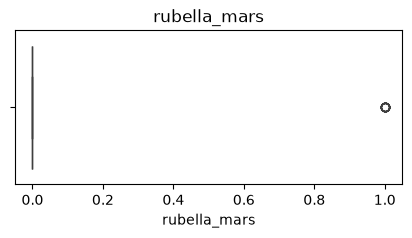

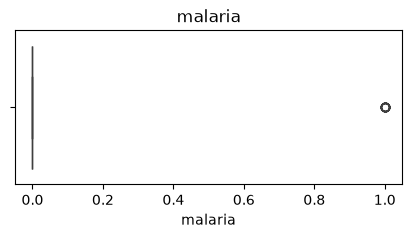

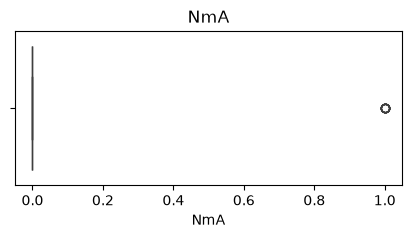

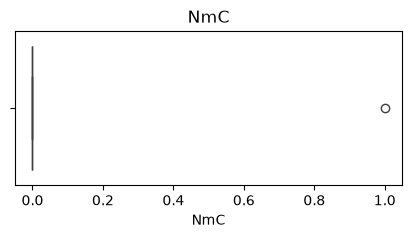

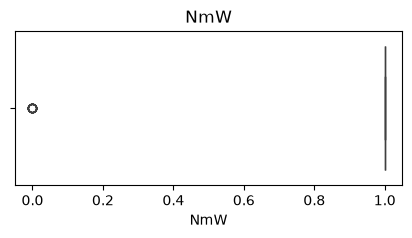

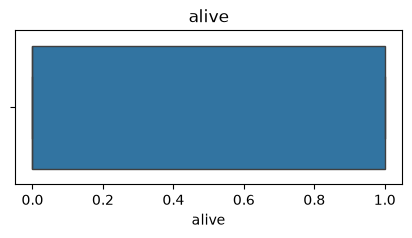

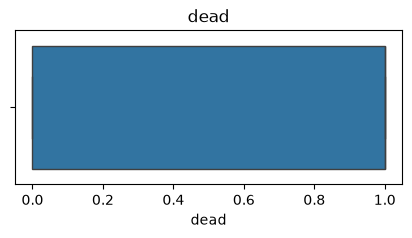

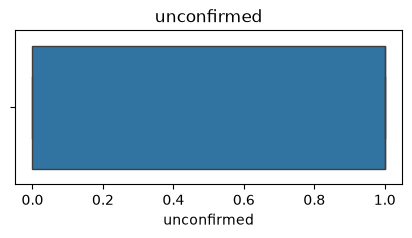

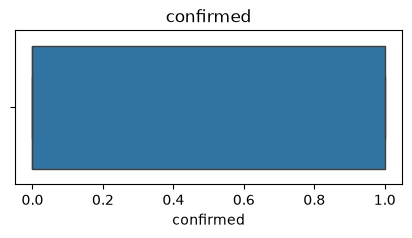

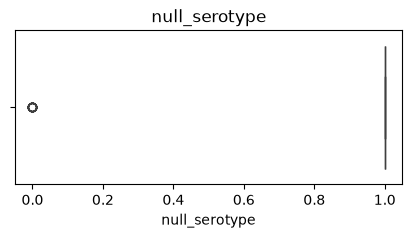

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
categorical = df.select_dtypes(include="object").columns

print(categorical)

Index(['surname', 'firstname', 'middlename', 'gender', 'state', 'settlement',
       'age_str', 'disease', 'serotype', 'health_status', 'report_outcome'],
      dtype='object')


In [15]:
df = pd.get_dummies(
    df,
    columns=["gender","state"],
    drop_first=True
)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["health_status"] = le.fit_transform(df["health_status"])

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["age"] = scaler.fit_transform(df[["age"]])

In [19]:
df.drop(columns=["surname", "firstname", "middlename" ], inplace=True)

In [20]:
numeric = df.select_dtypes(include=np.number)

print(numeric.skew())

gender_male                    0.197325
gender_female                 -0.197325
rural_settlement               0.072399
urban_settlement              -0.072399
report_year                   -0.110860
age                            0.235204
child_group                    0.787948
adult_group                   -0.787948
cholera                        2.174037
diarrhoea                      2.387366
measles                        2.312462
viral_haemmorrhaphic_fever     2.387366
meningitis                     3.200095
ebola                          3.875268
marburg_virus                  2.640332
yellow_fever                   2.736071
rubella_mars                   3.677399
malaria                        2.466627
NmA                            4.359698
NmC                           13.964240
NmW                           -3.875268
health_status                 -0.017063
alive                          0.093124
dead                          -0.093124
unconfirmed                   -0.893128


In [22]:
df.to_csv("cleaned_meningitis_dataset.csv", index=False)

In [27]:
print("Data preprocessing completed successfully. Cleaned dataset saved as 'cleaned_meningitis_dataset.csv'.")
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())


Data preprocessing completed successfully. Cleaned dataset saved as 'cleaned_meningitis_dataset.csv'.
   gender_male  gender_female settlement  rural_settlement  urban_settlement  \
0            0              1      Rural                 1                 0   
1            1              0      Rural                 1                 0   
2            0              1      Urban                 0                 1   
3            0              1      Rural                 1                 0   
4            1              0      Urban                 0                 1   

  report_date  report_year       age   age_str date_of_birth  ...  state_Ogun  \
0  2018-05-15         2018 -0.040394  32 years    1986-01-17  ...       False   
1  2017-02-28         2017 -0.040394  32 years    1985-09-01  ...       False   
2  2012-03-02         2012 -0.406761  24 years    1988-05-01  ...        True   
3  2010-05-21         2010  1.379278  63 years    1947-05-24  ...       False   
4  2017-08-2